 # Capstone (part 1): Model Building for Autonomous car driving system : Classification and Regression of the location

1. Data Setup

In [3]:
# Importing of necessary libraries
import numpy as np
import pandas as pd

import tensorflow as tf

from keras.models import Sequential

import matplotlib.pyplot as plt
import shutil
import os
import cv2
import PIL as IMAGE

2. Image loading and verification

In [4]:
# Creating the path for the archive file and the extracted file for unzip
archive_file="/content/drive/MyDrive/Abhijit/Capstone/Images.zip"
extracted_path="/content/drive/MyDrive/Abhijit/Capstone"


In [ ]:
# Unpacking the zip file with shutil library
shutil.unpack_archive(archive_file, extracted_path)
print(f"Successfully unpacked '{archive_file}' to '{extracted_path}'.")

In [5]:
# Load the data label file in data frame and check of the loaded data

df_labels=pd.read_csv(r"/content/drive/MyDrive/Abhijit/Capstone/labels.csv")
df_labels.head(5)

,id,car_type,x_min,y_min,x_max,y_max
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45


In [6]:
# Labeling the column of the loaded data
df_labels.columns = ["IMAGE_ID", "CLASS", "X_MIN", "Y_MIN", "X_MAX", "Y_MAX"]
df_labels.head()

,IMAGE_ID,CLASS,X_MIN,Y_MIN,X_MAX,Y_MAX
0,0,pickup_truck,213,34,255,50
1,0,car,194,78,273,122
2,0,car,155,27,183,35
3,0,articulated_truck,43,25,109,55
4,0,car,106,32,124,45


In [7]:
#Slicing the data upto 500 rows and check the shape and head of the sliced data
df_subset = df_labels.iloc[:500]
print(df_subset.shape)
print(df_subset.head())

(500, 6)
   IMAGE_ID              CLASS  X_MIN  Y_MIN  X_MAX  Y_MAX
0         0       pickup_truck    213     34    255     50
1         0                car    194     78    273    122
2         0                car    155     27    183     35
3         0  articulated_truck     43     25    109     55
4         0                car    106     32    124     45


In [8]:
# Check of the some images present in the image directory
print(os.listdir("/content/drive/MyDrive/Abhijit/Capstone/Images")[:3])

['00000144.jpg', '00000145.jpg', '00000148.jpg']


In [9]:
# Check of the image path based on the image ID connected to the data file i.e. data_subset
extracted_path = "/content/drive/MyDrive/Abhijit/Capstone/Images"

image_id = df_subset.iloc[11]["IMAGE_ID"]
img_path = os.path.join(extracted_path, f"{image_id:08d}.jpg")

print(img_path)

/content/drive/MyDrive/Abhijit/Capstone/Images/00000002.jpg


In [10]:
# sanity check
import os

print(os.path.exists(img_path))

True


array([[[ 5,  5,  5],
        [ 4,  4,  4],
        [ 3,  3,  3],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 5,  5,  5],
        [ 5,  5,  5],
        [ 4,  4,  4],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 6,  6,  6],
        [ 6,  6,  6],
        [ 5,  5,  5],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       ...,

       [[ 2,  0, 10],
        [ 6,  2, 14],
        [13, 11, 23],
        ...,
        [ 0,  3,  1],
        [ 3,  1,  0],
        [ 2,  0,  0]],

       [[ 2,  0, 10],
        [ 6,  2, 14],
        [13, 11, 23],
        ...,
        [ 0,  3,  1],
        [ 3,  1,  0],
        [ 2,  0,  0]],

       [[ 2,  0, 10],
        [ 6,  2, 14],
        [13, 11, 23],
        ...,
        [ 0,  3,  1],
        [ 3,  1,  0],
        [ 2,  0,  0]]], dtype=uint8)
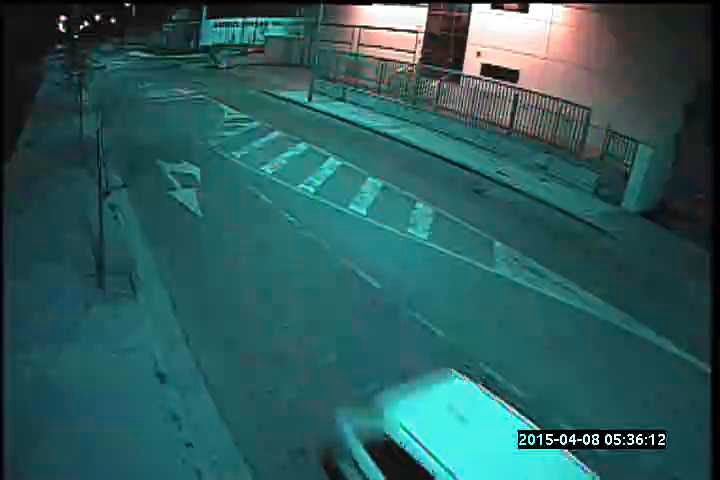

In [11]:
# read one images based on the image path
img = cv2.imread(img_path)
img


In [12]:
# check the number of files in the directory
len(os.listdir(extracted_path))

5626

3. Exploratory data Analysis

In [13]:
df_subset.columns

Index(['IMAGE_ID', 'CLASS', 'X_MIN', 'Y_MIN', 'X_MAX', 'Y_MAX'], dtype='object')

In [14]:
#check of the number of unique images present in the data
df_subset["IMAGE_ID"].unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153])

In [15]:
# check of the classes of car and their counts
df_subset["CLASS"].value_counts()

,count
CLASS,
car,354
pickup_truck,50
motorized_vehicle,31
work_van,17
bus,14
articulated_truck,14
pedestrian,7
single_unit_truck,6
bicycle,5


In [16]:
len(df_subset["CLASS"])

500

<Axes: xlabel='CLASS'>

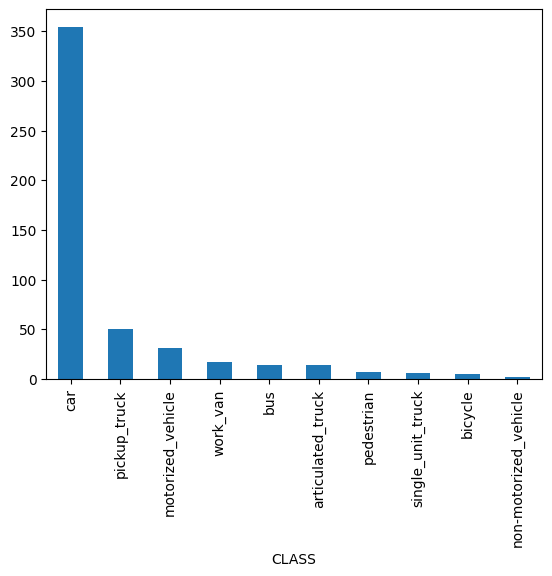

In [17]:
df_subset["CLASS"].value_counts().plot(kind="bar") # To check the imbalance in the data

In [18]:
# Checking the percentage of cars in 500 objects

per_car=len(df_subset[df_subset["CLASS"]=='car'])/len(df_subset)*100
per_car

70.8

In [19]:
# Grouping the ojects belongs to same image
for item in df_subset["CLASS"].unique():
  per_car=len(df_subset[df_subset["CLASS"]==item])/len(df_subset)*100
  print(f"{item}:{per_car:.2f}%")

pickup_truck:10.00%
car:70.80%
articulated_truck:2.80%
bus:2.80%
motorized_vehicle:6.20%
work_van:3.40%
single_unit_truck:1.20%
pedestrian:1.40%
bicycle:1.00%
non-motorized_vehicle:0.40%


Class imbalance:

1.  Data for car class is huge ~71% Therefore highly imbalanced.
2.  All other categories of images are also small. Like the percentages of bus is only 2.8% and pedestrian , non-motorized vehicle and bicycles classes are also small



In [20]:
df_subset["CLASS"].unique()

array(['pickup_truck', 'car', 'articulated_truck', 'bus',
       'motorized_vehicle', 'work_van', 'single_unit_truck', 'pedestrian',
       'bicycle', 'non-motorized_vehicle'], dtype=object)

In [21]:
# Encoding the class data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_subset['label_encoded'] = le.fit_transform(df_subset['CLASS'])

/tmp/ipykernel_258/2551047195.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['label_encoded'] = le.fit_transform(df_subset['CLASS'])


In [22]:
df_subset.head()

,IMAGE_ID,CLASS,X_MIN,Y_MIN,X_MAX,Y_MAX,label_encoded
0,0,pickup_truck,213,34,255,50,7
1,0,car,194,78,273,122,3
2,0,car,155,27,183,35,3
3,0,articulated_truck,43,25,109,55,0
4,0,car,106,32,124,45,3


In [23]:
grouped = df_subset.groupby("IMAGE_ID")
grouped

In [24]:
grouped.head()

,IMAGE_ID,CLASS,X_MIN,Y_MIN,X_MAX,Y_MAX,label_encoded
0,0,pickup_truck,213,34,255,50,7
1,0,car,194,78,273,122,3
2,0,car,155,27,183,35,3
3,0,articulated_truck,43,25,109,55,0
4,0,car,106,32,124,45,3
...,...,...,...,...,...,...,...
495,152,single_unit_truck,159,90,199,126,8
496,152,car,512,257,688,403,3
497,152,motorized_vehicle,158,92,205,117,4
498,153,work_van,142,35,294,117,9


In [25]:
len(grouped)

154

In [26]:
# Checking the group item
for img_id, group in grouped:
    print("Image ID:", img_id)
    print(group)
    break   # just to see one group

Image ID: 0
   IMAGE_ID              CLASS  X_MIN  Y_MIN  X_MAX  Y_MAX  label_encoded
0         0       pickup_truck    213     34    255     50              7
1         0                car    194     78    273    122              3
2         0                car    155     27    183     35              3
3         0  articulated_truck     43     25    109     55              0
4         0                car    106     32    124     45              3


In [27]:
df_subset.columns

Index(['IMAGE_ID', 'CLASS', 'X_MIN', 'Y_MIN', 'X_MAX', 'Y_MAX',
       'label_encoded'],
      dtype='object')

In [28]:
# Image list data creation based on the image-id and group and choose desire columns
image_data = []

for img_id, group in grouped:
    boxes = group[['X_MIN', 'Y_MIN', 'X_MAX', 'Y_MAX']].values
    labels = group['label_encoded'].values

    image_data.append({
        "image_id": img_id,
        "boxes": boxes,
        "labels": labels
    })

In [29]:
# check one image data
image_data[0]

{'image_id': 0,
 'boxes': array([[213,  34, 255,  50],
        [194,  78, 273, 122],
        [155,  27, 183,  35],
        [ 43,  25, 109,  55],
        [106,  32, 124,  45]]),
 'labels': array([7, 3, 3, 0, 3])}

In [30]:
# import cv2
# import numpy as np
# import os

# X = []
# y_bbox = []
# y_class = []

# IMG_SIZE = 224
# MAX_OBJS = 6  # Define the maximum number of objects per image

# for item in image_data:
#     img_id = item["image_id"]

#     # Corrected image path
#     img_path = os.path.join(extracted_path, f"{img_id:08d}.jpg")
#     img = cv2.imread(img_path)

#     if img is None:
#         continue

#     h_orig, w_orig = img.shape[:2]
#     img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

#     # Prepare empty arrays for this specific image
#     # Shape: (MAX_OBJS, 4) for boxes and (MAX_OBJS,) for labels
#     image_bboxes = np.zeros((MAX_OBJS, 4), dtype=np.float32) # Ensure dtype for consistency
#     image_labels = np.zeros((MAX_OBJS,), dtype=np.int32) # Initialize as integer array for encoded labels

#     #  LOOP through ALL objects instead of just the first one
#     for i, (bbox, label) in enumerate(zip(item["boxes"], item["labels"])):
#         if i >= MAX_OBJS:
#             break  # Stop if we hit our limit

#         x_min, y_min, x_max, y_max = bbox

#         # Scale and Normalize (keeping them between 0 and 1)
#         x_min_norm = x_min / w_orig
#         y_min_norm = y_min / h_orig
#         x_max_norm = x_max / w_orig
#         y_max_norm = y_max / h_orig

#         # Encode the label string to its numerical representation
#         # The LabelEncoder 'le' should be available from a previous cell (nVVAIv3e_ygQ).
#         encoded_label=[label][0]

#         image_bboxes[i] = [x_min_norm, y_min_norm, x_max_norm, y_max_norm]
#         image_labels[i] = encoded_label

#     X.append(img_resized)
#     y_bbox.append(image_bboxes)
#     y_class.append(image_labels)

# X = np.array(X, dtype=np.float32)
# y_bbox = np.array(y_bbox, dtype=np.float32) # Shape: (Total_Images, MAX_OBJS, 4)
# y_class = np.array(y_class, dtype=np.int32) # Shape: (Total_Images, MAX_OBJS)


In [31]:
import cv2
import numpy as np

X = []
y_bbox = []
y_class = []

IMG_SIZE = 224

for item in image_data:

    img_id = item["image_id"]

    # take first object (single detection)
    bbox = item["boxes"][0]
    label = item["labels"][0]

    # Corrected image path
    img_path = os.path.join(extracted_path, f"{img_id:08d}.jpg")

    img = cv2.imread(img_path)

    if img is None:
        print(f"Warning: Image not found or failed to load for ID {img_id} at path {img_path}. Skipping.")
        continue # Skip this item and proceed to the next one

    # original size
    h_orig, w_orig = img.shape[:2]

    # resize image
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_resized = img_resized / 255.0

    # unpack bbox
    x_min, y_min, x_max, y_max = bbox

    # 🔥 SCALE bbox to resized image

    scale_x = IMG_SIZE / w_orig
    scale_y = IMG_SIZE / h_orig

    x_min = x_min * scale_x
    x_max = x_max * scale_x
    y_min = y_min * scale_y
    y_max = y_max * scale_y

    # 🔥 NORMALIZE (0–1)
    x_min /= IMG_SIZE
    x_max /= IMG_SIZE
    y_min /= IMG_SIZE
    y_max /= IMG_SIZE

    bbox_final = [x_min, y_min, x_max, y_max]

    # store
    X.append(img_resized)
    y_bbox.append(bbox_final)
    y_class.append(label)

# convert to numpy
X = np.array(X)
y_bbox = np.array(y_bbox)
y_class = np.array(y_class)

In [32]:
len(X)

153

In [33]:
len(y_bbox)

153

In [34]:
len(y_class)

153

In [106]:
len(y_class)

153

In [32]:
# Train and testing data creation
from sklearn.model_selection import train_test_split

X_train, X_test, y_bbox_train, y_bbox_test, y_class_train, y_class_test = train_test_split(
    X, y_bbox, y_class, test_size=0.2, random_state=42
)

In [33]:
# number of claases in the data
num_classes = len(df_subset["CLASS"].unique())

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Input
input_layer = tf.keras.Input(shape=(224, 224, 3))

#  Convolutional Stack
x = layers.Conv2D(32, (3,3), activation='relu')(input_layer)
x = layers.MaxPooling2D((2,2))(x)
x = layers.BatchNormalization()(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

#  Dense / Shared Representation
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

#  HEAD 1: Classification
class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(x)

#  HEAD 2: Bounding Box
bbox_output = layers.Dense(4, activation='sigmoid', name='bbox_output')(x)

# final Model
model = models.Model(inputs=input_layer, outputs=[class_output, bbox_output])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 111,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 54, 54,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 52, 52,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 26, 26,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 86528)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │ 11,075,712 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 10)        │      1,290 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,170,894 (42.61 MB)

 Trainable params: 11,170,830 (42.61 MB)

 Non-trainable params: 64 (256.00 B)

In [187]:
# Compilation of the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'class_output': 'sparse_categorical_crossentropy',
        'bbox_output': 'mse'  # but Huber loss is better than MSE

    },
    loss_weights={
        'class_output': 1.0,
        'bbox_output': 10.0   # IMPORTANT for bbox learning
    },
    metrics={
        'class_output': 'accuracy',
        'bbox_output': 'mae'
    }
)

In [188]:
# Fitting data with the model
history = model.fit(
    X_train,
    {
        'class_output': y_class_train,
        'bbox_output': y_bbox_train
    },
    validation_data=(
        X_test,
        {
            'class_output': y_class_test,
            'bbox_output': y_bbox_test
        }
    ),
    batch_size=32,
    epochs=20
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - bbox_output_loss: 0.0476 - bbox_output_mae: 0.1726 - class_output_accuracy: 0.8852 - class_output_loss: 0.4422 - loss: 0.9184 - val_bbox_output_loss: 0.0595 - val_bbox_output_mae: 0.2073 - val_class_output_accuracy: 0.6774 - val_class_output_loss: 1.9360 - val_loss: 2.5308
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - bbox_output_loss: 0.0439 - bbox_output_mae: 0.1658 - class_output_accuracy: 0.8852 - class_output_loss: 0.3878 - loss: 0.8340 - val_bbox_output_loss: 0.0559 - val_bbox_output_mae: 0.1980 - val_class_output_accuracy: 0.6774 - val_class_output_loss: 1.9680 - val_loss: 2.5268
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - bbox_output_loss: 0.0367 - bbox_output_mae: 0.1526 - class_output_accuracy: 0.9180 - class_output_loss: 0.3425 - loss: 0.7152 - val_bbox_output_loss: 0.0577 - val_bbox_output_mae: 0.2028 - val_class_output_accuracy: 0.6452 - val_class_output_loss: 1.9519 - val_loss: 2.5289
Epoch 4/20
4/4 ━━━━━━━━━━━━━

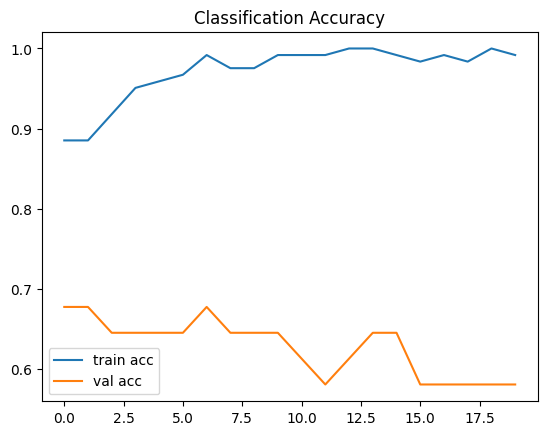

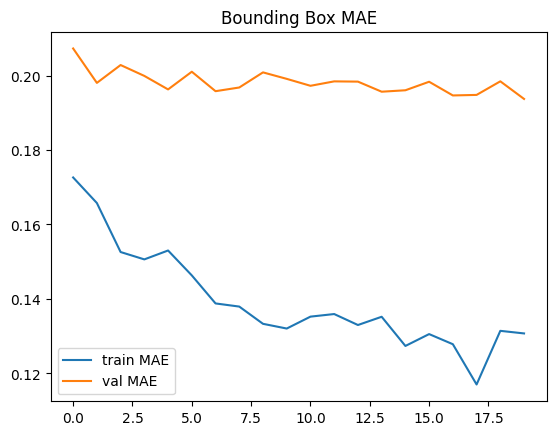

In [189]:
import matplotlib.pyplot as plt

# Classification accuracy
plt.plot(history.history['class_output_accuracy'], label='train acc')
plt.plot(history.history['val_class_output_accuracy'], label='val acc')
plt.legend()
plt.title("Classification Accuracy")
plt.show()

# Bounding box MAE
plt.plot(history.history['bbox_output_mae'], label='train MAE')
plt.plot(history.history['val_bbox_output_mae'], label='val MAE')
plt.legend()
plt.title("Bounding Box MAE")
plt.show()

In [190]:
# Evaluation of the model based on the training
results = model.evaluate(
    X_test,
    {
        'class_output': y_class_test,
        'bbox_output': y_bbox_test
    }
)

print(results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step - bbox_output_loss: 0.0531 - bbox_output_mae: 0.1937 - class_output_accuracy: 0.5806 - class_output_loss: 1.8487 - loss: 2.3800
[2.380016565322876, 1.8486601114273071, 0.05313565209507942, 0.19370827078819275, 0.5806451439857483]


In [211]:
# Prediction for an image
pred_class, pred_bbox = model.predict(X_test[:1])
print("Pred_class", pred_class)
print("Pred bbox:", pred_bbox[0])
print("True bbox:", y_bbox_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Pred_class [[0.08424219 0.07668635 0.07780737 0.22102389 0.10148125 0.10575514
  0.07403234 0.09695716 0.07494647 0.08706787]]
Pred bbox: [0.47970903 0.4465876  0.53421664 0.4825573 ]
True bbox: [0.65789474 0.49561404 0.88888889 0.69736842]


In [192]:
# Conversion function of xyxy to the pixel dimension 224*224
def xyxy_to_pixel(box, img_size=224):
    x_min, y_min, x_max, y_max = box

    x_min = int(x_min * img_size)
    y_min = int(y_min * img_size)
    x_max = int(x_max * img_size)
    y_max = int(y_max * img_size)

    return x_min, y_min, x_max, y_max

In [193]:
# cisualization Function for prediction output
import matplotlib.pyplot as plt
import cv2

def visualize_prediction(image, pred_box, true_box):

    img = (image * 255).astype("uint8").copy()

    # convert boxes
    pred_xyxy = xyxy_to_pixel(pred_box)
    true_xyxy = xyxy_to_pixel(true_box)

    # draw predicted box (GREEN)
    cv2.rectangle(img,
                  (pred_xyxy[0], pred_xyxy[1]),
                  (pred_xyxy[2], pred_xyxy[3]),
                  (0,255,0), 2)

    # draw true box (RED)
    cv2.rectangle(img,
                  (true_xyxy[0], true_xyxy[1]),
                  (true_xyxy[2], true_xyxy[3]),
                  (255,0,0), 2)

    plt.imshow(img)
    plt.title("Green = Predicted | Red = Ground Truth")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


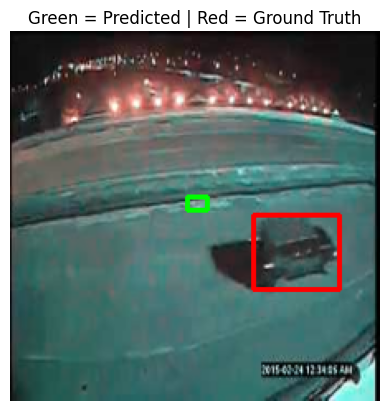

In [194]:
# check prediction for an image data
idx = 0

image = X_test[idx]
true_box = y_bbox_test[idx] # Corrected: Removed the extra [0] index

pred_class, pred_bbox = model.predict(X_test[idx:idx+1])

pred_box = pred_bbox[0]   # Select the first predicted bounding box for the first image

visualize_prediction(image, pred_box, true_box)

In [195]:
# Building of the intersection over union loss function
def iou_loss(y_true, y_pred):
    x1 = tf.maximum(y_true[:,0], y_pred[:,0])
    y1 = tf.maximum(y_true[:,1], y_pred[:,1])
    x2 = tf.minimum(y_true[:,2], y_pred[:,2])
    y2 = tf.minimum(y_true[:,3], y_pred[:,3])

    inter = tf.maximum(0.0, x2-x1) * tf.maximum(0.0, y2-y1)

    area1 = (y_true[:,2]-y_true[:,0]) * (y_true[:,3]-y_true[:,1])
    area2 = (y_pred[:,2]-y_pred[:,0]) * (y_pred[:,3]-y_pred[:,1])

    union = area1 + area2 - inter

    iou = inter / (union + 1e-6)

    return 1 - iou

In [196]:
import tensorflow as tf

iou_threshold = 0.75
correct = 0

pred_class, pred_bbox = model.predict(X_test)

for i in range(len(X_test)):

    # predicted class
    pred_label = pred_class[i].argmax()

    # true class
    true_label = y_class_test[i]

    # predicted bbox
    # Expand dimensions to make it (1, 4) instead of (4,) and cast to float32
    pb_single = tf.cast(tf.expand_dims(pred_bbox[i], axis=0), tf.float32)

    # true bbox
    # Expand dimensions to make it (1, 4) instead of (4,) and cast to float32
    tb_single = tf.cast(tf.expand_dims(y_bbox_test[i], axis=0), tf.float32)

    # iou_loss returns (1 - actual_iou), so we subtract from 1 to get the actual IoU
    actual_iou = 1 - iou_loss(tb_single, pb_single)

    if pred_label == true_label and actual_iou >= iou_threshold:
        correct += 1

map_score = correct / len(X_test)

print("mAP (IoU=", iou_threshold, "):", map_score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
mAP (IoU= 0.75 ): 0.0


# With VGG16





In [36]:
from keras.applications.vgg16 import VGG16

In [37]:
# Model architecture with the pretrained VGG model
#-------------------------------
import tensorflow as tf
from tensorflow.keras import layers, Model

img_size = 224

inputs = tf.keras.Input(shape=(img_size, img_size, 3))

# VGG16 BACKBONE MODEL
base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size, img_size, 3)
)

# Freeze backbone initially
base_model.trainable = False

# Pass input through VGG
x = base_model(inputs, training=False)

# ---------------------------
#  PASSING IT INTO THE CUSTOM CONVOLUTION HEAD
# ---------------------------
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x) # BATCH NORMALIZATION TO SCALE THE DATA : mean of zero and variance of one
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# ---------------------------
# FLATTEN + DENSE
# ---------------------------
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# ---------------------------
#  DUAL HEADS DESIGN
# ---------------------------

# Classification head
class_output = layers.Dense(
    num_classes,
    activation='softmax',
    name='class_output'
)(x)

# Bounding box head
bbox_output = layers.Dense(
    4,
    activation='sigmoid',  # normalized bbox
    name='bbox_output'
)(x)

# ---------------------------
# FINAL VGG MODEL
# ---------------------------
model_VGG = Model(inputs=inputs, outputs=[class_output, bbox_output])

model_VGG.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 32)  │    147,488 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 32)  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 3, 3, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 3, 3, 64)  │     18,496 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 3, 64)  │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 3, 3, 128) │     73,856 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 3, 128) │        512 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 1, 1, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 128)       │          0 │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 10)        │      1,290 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        516 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,973,742 (57.12 MB)

 Trainable params: 258,606 (1010.18 KB)

 Non-trainable params: 14,715,136 (56.13 MB)

In [38]:
# Compilation of the model
model_VGG.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'class_output': 'sparse_categorical_crossentropy',
        'bbox_output': 'mse'  # but Huber loss is better than MSE

    },
    loss_weights={
        'class_output': 1.0,
        'bbox_output': 10.0   # IMPORTANT for bbox learning
    },
    metrics={
        'class_output': 'accuracy',
        'bbox_output': 'mae'
    }
)

In [203]:
# Fitting data with the model
history = model_VGG.fit(
    X_train,
    {
        'class_output': y_class_train,
        'bbox_output': y_bbox_train
    },
    validation_data=(
        X_test,
        {
            'class_output': y_class_test,
            'bbox_output': y_bbox_test
        }
    ),
    batch_size=32,
    epochs=20
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 76s 19s/step - bbox_output_loss: 0.1616 - bbox_output_mae: 0.3290 - class_output_accuracy: 0.2213 - class_output_loss: 2.6895 - loss: 4.3258 - val_bbox_output_loss: 0.0736 - val_bbox_output_mae: 0.2365 - val_class_output_accuracy: 0.3548 - val_class_output_loss: 2.1669 - val_loss: 2.9028
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 81s 19s/step - bbox_output_loss: 0.1428 - bbox_output_mae: 0.3118 - class_output_accuracy: 0.4016 - class_output_loss: 1.8049 - loss: 3.2502 - val_bbox_output_loss: 0.0720 - val_bbox_output_mae: 0.2335 - val_class_output_accuracy: 0.6129 - val_class_output_loss: 2.1352 - val_loss: 2.8551
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 65s 16s/step - bbox_output_loss: 0.1259 - bbox_output_mae: 0.2895 - class_output_accuracy: 0.5082 - class_output_loss: 1.5622 - loss: 2.8275 - val_bbox_output_loss: 0.0704 - val_bbox_output_mae: 0.2305 - val_class_output_accuracy: 0.6774 - val_class_output_loss: 2.1066 - val_loss: 2.8108
Epoch 4/20
4/4 ━━━━━━━━━━

In [214]:
# Evaluation of the model based on the training
results_VGG = model_VGG.evaluate(
    X_test,
    {
        'class_output': y_class_test,
        'bbox_output': y_bbox_test
    }
)

print(results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - bbox_output_loss: 0.0611 - bbox_output_mae: 0.2119 - class_output_accuracy: 0.5806 - class_output_loss: 2.0035 - loss: 2.6144
[2.380016565322876, 1.8486601114273071, 0.05313565209507942, 0.19370827078819275, 0.5806451439857483]


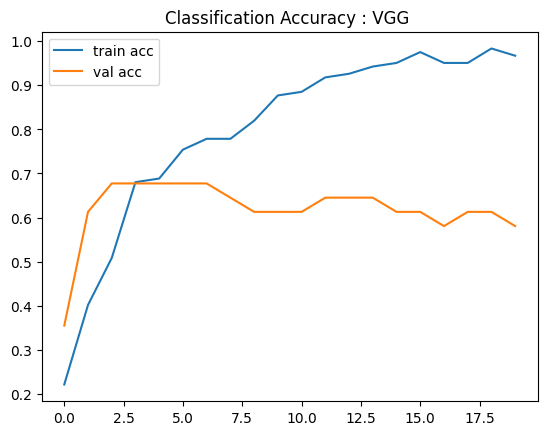

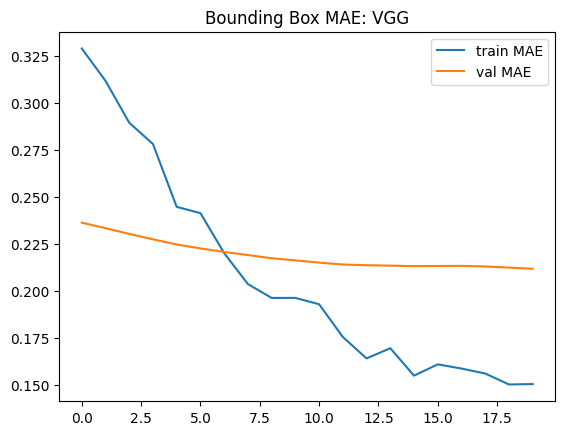

In [216]:
import matplotlib.pyplot as plt

# Classification accuracy
plt.plot(history.history['class_output_accuracy'], label='train acc')
plt.plot(history.history['val_class_output_accuracy'], label='val acc')
plt.legend()
plt.title("Classification Accuracy : VGG ")
plt.show()

# Bounding box MAE
plt.plot(history.history['bbox_output_mae'], label='train MAE')
plt.plot(history.history['val_bbox_output_mae'], label='val MAE')
plt.legend()
plt.title("Bounding Box MAE: VGG")
plt.show()

* Accuracy and bounding box prediction alsmost remain same after using the pretrained VGG16 model. Possibly it might be due to the less number of training examples. So, image augmentation can improves the performace of the model *


In [205]:
# Prediction for an image
pred_class_VGG, pred_bbox_VGG = model_VGG.predict(X_test[:1])
print("Pred_class", pred_class_VGG)
print("Pred bbox:", pred_bbox_VGG[0])
print("True bbox:", y_bbox_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step
Pred_class [[0.10536961 0.08688191 0.09570623 0.13822056 0.08041424 0.10533883
  0.09554451 0.11174931 0.08198519 0.09878957]]
Pred bbox: [0.4799989  0.49857607 0.54345256 0.51568824]
True bbox: [0.65789474 0.49561404 0.88888889 0.69736842]


In [206]:
# Conversion function of xyxy to the pixel dimension 224*224
def xyxy_to_pixel(box, img_size=224):
    x_min, y_min, x_max, y_max = box

    x_min = int(x_min * img_size)
    y_min = int(y_min * img_size)
    x_max = int(x_max * img_size)
    y_max = int(y_max * img_size)

    return x_min, y_min, x_max, y_max

In [207]:
# cisualization Function for prediction output
import matplotlib.pyplot as plt
import cv2

def visualize_prediction(image, pred_box, true_box):

    img = (image * 255).astype("uint8").copy()

    # convert boxes
    pred_xyxy = xyxy_to_pixel(pred_box)
    true_xyxy = xyxy_to_pixel(true_box)

    # draw predicted box (GREEN)
    cv2.rectangle(img,
                  (pred_xyxy[0], pred_xyxy[1]),
                  (pred_xyxy[2], pred_xyxy[3]),
                  (0,255,0), 2)

    # draw true box (RED)
    cv2.rectangle(img,
                  (true_xyxy[0], true_xyxy[1]),
                  (true_xyxy[2], true_xyxy[3]),
                  (255,0,0), 2)

    plt.imshow(img)
    plt.title("Green = Predicted | Red = Ground Truth")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step


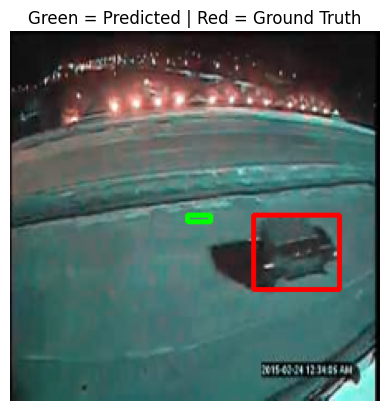

In [208]:
# check prediction for an image data
idx = 0

image = X_test[idx]
true_box = y_bbox_test[idx] # Corrected: Removed the extra [0] index

pred_class_VGG, pred_bbox_VGG = model_VGG.predict(X_test[idx:idx+1])

pred_box_VGG = pred_bbox_VGG[0]   # Select the first predicted bounding box for the first image

visualize_prediction(image, pred_box_VGG, true_box)

In [209]:
# Building of the intersection over union loss function
def iou_loss(y_true, y_pred):
    x1 = tf.maximum(y_true[:,0], y_pred[:,0])
    y1 = tf.maximum(y_true[:,1], y_pred[:,1])
    x2 = tf.minimum(y_true[:,2], y_pred[:,2])
    y2 = tf.minimum(y_true[:,3], y_pred[:,3])

    inter = tf.maximum(0.0, x2-x1) * tf.maximum(0.0, y2-y1)

    area1 = (y_true[:,2]-y_true[:,0]) * (y_true[:,3]-y_true[:,1])
    area2 = (y_pred[:,2]-y_pred[:,0]) * (y_pred[:,3]-y_pred[:,1])

    union = area1 + area2 - inter

    iou = inter / (union + 1e-6)

    return 1 - iou

In [210]:
import tensorflow as tf

iou_threshold = 0.75
correct = 0

pred_class, pred_bbox = model.predict(X_test)

for i in range(len(X_test)):

    # predicted class
    pred_label = pred_class[i].argmax()

    # true class
    true_label = y_class_test[i]

    # predicted bbox
    # Expand dimensions to make it (1, 4) instead of (4,) and cast to float32
    pb_single = tf.cast(tf.expand_dims(pred_bbox[i], axis=0), tf.float32)

    # true bbox
    # Expand dimensions to make it (1, 4) instead of (4,) and cast to float32
    tb_single = tf.cast(tf.expand_dims(y_bbox_test[i], axis=0), tf.float32)

    # iou_loss returns (1 - actual_iou), so we subtract from 1 to get the actual IoU
    actual_iou = 1 - iou_loss(tb_single, pb_single)

    if pred_label == true_label and actual_iou >= iou_threshold:
        correct += 1

map_score = correct / len(X_test)

print("mAP (IoU=", iou_threshold, "):", map_score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step
mAP (IoU= 0.75 ): 0.0


In [213]:
pred_class_VGG, pred_bbox_VGG = model_VGG.predict(X_test[:5])

print("Pred bbox:", pred_bbox_VGG[0])
print("True bbox):", y_bbox_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Pred bbox: [0.47999892 0.4985761  0.5434525  0.5156881 ]
True bbox): [0.65789474 0.49561404 0.88888889 0.69736842]


# Augmentation of the data and model building with the pretrained VGG model

 VGG model with Augmented data

In [39]:
# image Augmentation by brightness tuning
from tensorflow.keras.preprocessing.image import ImageDataGenerator

brightness_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.5, 2.0]
)

In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Comprehensive augmentation setup
advanced_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.5, 1.5],   # Randomly change brightness
    # rotation_range=30,             # Rotate up to 30 degrees
    width_shift_range=0.2,         # Shift horizontally
    height_shift_range=0.2,        # Shift vertically
    # shear_range=0.2,               # Distort the image (tilt)
    zoom_range=0.2,                # Randomly zoom in/out
    horizontal_flip=True,          # Flip horizontally
    # fill_mode='nearest'            # Fills empty pixels created by rotation
)

def augmented_generator(X, y_class, y_bbox, batch_size):
    # Using the updated 'advanced_datagen' here
    gen = advanced_datagen.flow(X, batch_size=batch_size, shuffle=True)

    while True:
        batch_X = next(gen)

        # Get indices of this batch to align labels and bounding boxes
        idx = gen.index_array[:len(batch_X)]

        batch_y_class = y_class[idx]
        batch_y_bbox = y_bbox[idx]

        yield batch_X, {
            'class_output': batch_y_class,
            'bbox_output': batch_y_bbox
        }

In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# ONLY use augmentations that don't move the object's position
# Brightness is the only truly "safe" one here without extra math
safe_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.5, 1.5]
)

def augmented_generator(X, y_class, y_bbox, batch_size):
    gen = safe_datagen.flow(X, batch_size=batch_size, shuffle=True)

    while True:
        batch_X = next(gen)
        idx = gen.index_array[:len(batch_X)]

        batch_y_class = y_class[idx]
        batch_y_bbox = y_bbox[idx] # Now these actually match the image!

        yield batch_X, {
            'class_output': batch_y_class,
            'bbox_output': batch_y_bbox
        }

In [62]:
#VGG Model fit with the Augmented data with decreasing the batch size and increasing the epochs and augmented data
batch_size = 16

train_gen = augmented_generator(X_train, y_class_train, y_bbox_train, batch_size)

history_VGG_Aug=model_VGG.fit(
    train_gen,
    steps_per_epoch=len(X_train)//batch_size,
    validation_data=(
        X_test,
        {
            'class_output': y_class_test,
            'bbox_output': y_bbox_test
        }
    ),
    epochs=20
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 88s 13s/step - bbox_output_loss: 0.0654 - bbox_output_mae: 0.2033 - class_output_accuracy: 0.5714 - class_output_loss: 1.3408 - loss: 1.9953 - val_bbox_output_loss: 0.1614 - val_bbox_output_mae: 0.3165 - val_class_output_accuracy: 0.0000e+00 - val_class_output_loss: 4.3230 - val_loss: 5.9370
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 13s/step - bbox_output_loss: 0.0623 - bbox_output_mae: 0.1992 - class_output_accuracy: 0.7075 - class_output_loss: 1.0404 - loss: 1.6515 - val_bbox_output_loss: 0.1684 - val_bbox_output_mae: 0.3216 - val_class_output_accuracy: 0.0000e+00 - val_class_output_loss: 4.4616 - val_loss: 6.1459
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 13s/step - bbox_output_loss: 0.0620 - bbox_output_mae: 0.1941 - class_output_accuracy: 0.6509 - class_output_loss: 1.4526 - loss: 2.0812 - val_bbox_output_loss: 0.1760 - val_bbox_output_mae: 0.3278 - val_class_output_accuracy: 0.0000e+00 - val_class_output_loss: 4.5924 - val_loss: 6.3529
Epoch 4/20
7/

In [63]:
# Evaluation of the model based on the training
results_VGG_AUG = model_VGG.evaluate(
    X_test,
    {
        'class_output': y_class_test,
        'bbox_output': y_bbox_test
    }
)

print(results_VGG_AUG)


1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step - bbox_output_loss: 0.2156 - bbox_output_mae: 0.3813 - class_output_accuracy: 0.0000e+00 - class_output_loss: 7.6910 - loss: 9.8471
[9.84708023071289, 7.691030025482178, 0.2156049907207489, 0.38127848505973816, 0.0]


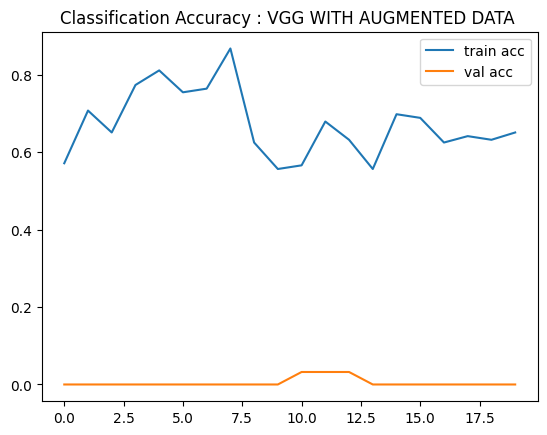

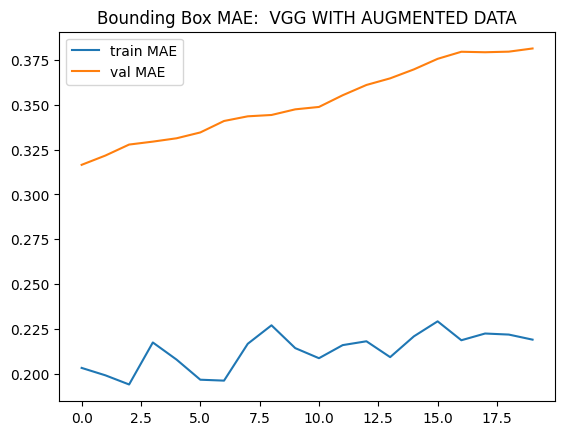

In [64]:
import matplotlib.pyplot as plt

# Classification accuracy
plt.plot(history_VGG_Aug.history['class_output_accuracy'], label='train acc')
plt.plot(history_VGG_Aug.history['val_class_output_accuracy'], label='val acc')
plt.legend()
plt.title("Classification Accuracy : VGG WITH AUGMENTED DATA ")
plt.show()

# Bounding box MAE
plt.plot(history_VGG_Aug.history['bbox_output_mae'], label='train MAE')
plt.plot(history_VGG_Aug.history['val_bbox_output_mae'], label='val MAE')
plt.legend()
plt.title("Bounding Box MAE:  VGG WITH AUGMENTED DATA")
plt.show()

In [67]:
# Prediction for an image
pred_class_VGG_AUG, pred_bbox_VGG_AUG = model_VGG.predict(X_test[:1])
print("Pred_class", pred_class_VGG_AUG)
print("Pred bbox:", pred_bbox_VGG_AUG[0])
print("True bbox:", y_bbox_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step
Pred_class [[0.00308364 0.11614902 0.08559431 0.01386244 0.07150881 0.00965585
  0.09543294 0.02526081 0.5590053  0.02044681]]
Pred bbox: [0.8757985  0.22037223 0.94594264 0.05828416]
True bbox: [0.65789474 0.49561404 0.88888889 0.69736842]


In [ ]:
# Prob of Class 8 is highest which corresponds to

In [78]:
df_class=df_subset[['CLASS', 'label_encoded']].drop_duplicates().sort_values('label_encoded')
df_class['CLASS'].to_list()

['articulated_truck',
 'bicycle',
 'bus',
 'car',
 'motorized_vehicle',
 'non-motorized_vehicle',
 'pedestrian',
 'pickup_truck',
 'single_unit_truck',
 'work_van']

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step


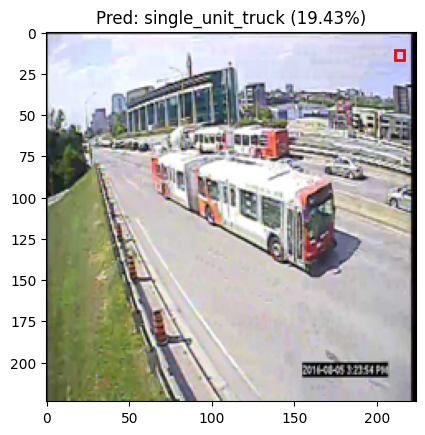

In [85]:
import tensorflow as tf
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def test_model_on_internet_image(img_url, model, class_names, img_size=224):
    # 1. Download the image
    response = requests.get(img_url)
    img = Image.open(BytesIO(response.content)).convert('RGB')

    # 2. Preprocess (Must match your Training exactly!)
    img_resized = img.resize((img_size, img_size))
    img_array = np.array(img_resized) / 255.0  # Rescale 1./255
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # 3. Predict
    predictions = model.predict(img_array)

    # Extract results based on your model's output names
    # Assuming predictions is a list: [class_output_array, bbox_output_array]
    pred_class_logits = predictions[0] # First element is class output
    pred_bbox = predictions[1][0]    # Second element is bbox output

    # Get class name
    class_idx = np.argmax(pred_class_logits)
    predicted_label = class_names[class_idx]
    confidence = np.max(tf.nn.softmax(pred_class_logits))

    # 4. Visualize
    fig, ax = plt.subplots(1)
    ax.imshow(img_resized)

    # Draw Bounding Box
    # Convert normalized [0,1] to pixel values
    xmin, ymin, xmax, ymax = pred_bbox
    width = (xmax - xmin) * img_size
    height = (ymax - ymin) * img_size

    rect = patches.Rectangle((xmin * img_size, ymin * img_size),
                             width, height,
                             linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    plt.title(f"Pred: {predicted_label} ({confidence*100:.2f}%)")
    plt.show()

# --- Execution ---
# Replace with your actual list of classes
my_classes = ['articulated_truck',
 'bicycle',
 'bus',
 'car',
 'motorized_vehicle',
 'non-motorized_vehicle',
 'pedestrian',
 'pickup_truck',
 'single_unit_truck',
 'work_van']

# Example URL (replace with any image link)
# url = "https://drive.google.com/file/d/14lB-RP8Ip6Foclrl-S6EFhp0yntjks07/view?usp=sharing"
url = "https://drive.google.com/uc?export=download&id=14lB-RP8Ip6Foclrl-S6EFhp0yntjks07"
test_model_on_internet_image(url, model_VGG, my_classes)


In [46]:
# Conversion function of xyxy to the pixel dimension 224*224
def xyxy_to_pixel(box, img_size=224):
    x_min, y_min, x_max, y_max = box

    x_min = int(x_min * img_size)
    y_min = int(y_min * img_size)
    x_max = int(x_max * img_size)
    y_max = int(y_max * img_size)

    return x_min, y_min, x_max, y_max

In [47]:
# cisualization Function for prediction output
import matplotlib.pyplot as plt
import cv2

def visualize_prediction(image, pred_box, true_box):

    img = (image * 255).astype("uint8").copy()

    # convert boxes
    pred_xyxy = xyxy_to_pixel(pred_box)
    true_xyxy = xyxy_to_pixel(true_box)

    # draw predicted box (GREEN)
    cv2.rectangle(img,
                  (pred_xyxy[0], pred_xyxy[1]),
                  (pred_xyxy[2], pred_xyxy[3]),
                  (0,255,0), 2)

    # draw true box (RED)
    cv2.rectangle(img,
                  (true_xyxy[0], true_xyxy[1]),
                  (true_xyxy[2], true_xyxy[3]),
                  (255,0,0), 2)

    plt.imshow(img)
    plt.title("Green = Predicted | Red = Ground Truth")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step


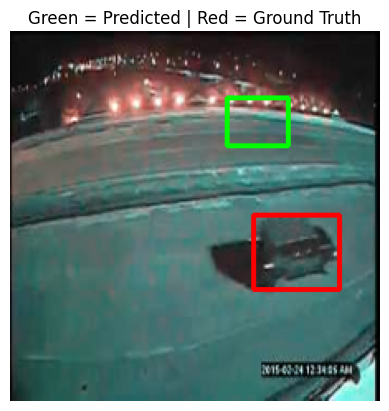

In [60]:
# check prediction for an image data
idx = 0

image = X_test[idx]
true_box = y_bbox_test[idx] # Corrected: Removed the extra [0] index

pred_class_VGG_AUG, pred_bbox_VGG_AUG = model_VGG.predict(X_test[idx:idx+1])

pred_box_VGG_AUG = pred_bbox_VGG_AUG[0]   # Select the first predicted bounding box for the first image

visualize_prediction(image, pred_box_VGG_AUG, true_box)

In [50]:
# Building of the intersection over union loss function
def iou_loss(y_true, y_pred):
    x1 = tf.maximum(y_true[:,0], y_pred[:,0])
    y1 = tf.maximum(y_true[:,1], y_pred[:,1])
    x2 = tf.minimum(y_true[:,2], y_pred[:,2])
    y2 = tf.minimum(y_true[:,3], y_pred[:,3])

    inter = tf.maximum(0.0, x2-x1) * tf.maximum(0.0, y2-y1)

    area1 = (y_true[:,2]-y_true[:,0]) * (y_true[:,3]-y_true[:,1])
    area2 = (y_pred[:,2]-y_pred[:,0]) * (y_pred[:,3]-y_pred[:,1])

    union = area1 + area2 - inter

    iou = inter / (union + 1e-6)

    return 1 - iou

In [52]:
import tensorflow as tf

iou_threshold = 0.75
correct = 0

pred_class_VGG_AUG, pred_bbox_VGG_AUG = model_VGG.predict(X_test)

for i in range(len(X_test)):

    # predicted class
    pred_label = pred_class_VGG_AUG[i].argmax()

    # true class
    true_label = y_class_test[i]

    # predicted bbox
    # Expand dimensions to make it (1, 4) instead of (4,) and cast to float32
    pb_single = tf.cast(tf.expand_dims(pred_bbox_VGG_AUG[i], axis=0), tf.float32)

    # true bbox
    # Expand dimensions to make it (1, 4) instead of (4,) and cast to float32
    tb_single = tf.cast(tf.expand_dims(y_bbox_test[i], axis=0), tf.float32)

    # iou_loss returns (1 - actual_iou), so we subtract from 1 to get the actual IoU
    actual_iou = 1 - iou_loss(tb_single, pb_single)

    if pred_label == true_label and actual_iou >= iou_threshold:
        correct += 1

map_score = correct / len(X_test)

print("mAP (IoU=", iou_threshold, "):", map_score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
mAP (IoU= 0.75 ): 0.0


In [54]:
pred_class_VGG_AUG, pred_bbox_VGG_AUG = model_VGG.predict(X_test[:5])

print("Pred bbox:", pred_bbox_VGG_AUG[0])
print("True bbox):", y_bbox_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Pred bbox: [0.58809537 0.31123918 0.7522585  0.18063477]
True bbox): [0.65789474 0.49561404 0.88888889 0.69736842]



1.  Accuracy and bounding box prediction are become worst here as the model uses the augmented data.
2.  It is unlcear the orgin of the problem in the code. Now it is predicting the box with valid coordinates but the true and predicted box are far appart
3.
